### Statistical Pattern Recognition

**Computer Homework #03**

**Alireza Mahdizadeh 40416814**

In [20]:
import pandas as pd
import numpy as np

In [21]:

FILE_PATH = 'Computer_Assignment_4_Data.xls'
LEARNING_RATE = 0.2
EPOCHS = 500

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)


In [22]:

def load_data(file_path):
    # --- Load Training Set ---
    # Try header=1 (skipping the title row) which is standard for these assignments
    # If that fails to find 'x1', we fallback to header=0
    try:
        train_df = pd.read_excel(file_path, sheet_name='Training Set', header=1)
        train_df.columns = train_df.columns.str.strip()
        
        if 'x1' not in train_df.columns:
            train_df = pd.read_excel(file_path, sheet_name='Training Set', header=0)
            train_df.columns = train_df.columns.str.strip()
            
    except Exception as e:
        print(f"Debug - Available columns found: {train_df.columns}")
        raise e

    X_train = train_df[['x1', 'x2']].values
    
    X_train = np.hstack((X_train, np.ones((X_train.shape[0], 1))))
    
    # Prepare Targets
    # Check what the class column is actually named. 
    # Usually it is "Class #" or "Class". We find the column that contains "Class"
    class_col = [c for c in train_df.columns if "Class" in c][0]
    
    y_train = []
    for cls in train_df[class_col]:
        if cls == 1:
            y_train.append([0.95, 0.05])
        else:
            y_train.append([0.05, 0.95])
    y_train = np.array(y_train)

    test_df = pd.read_excel(file_path, sheet_name='Testing Set', header=1)
    test_df.columns = test_df.columns.str.strip()
    
    if 'x1' not in test_df.columns:
         test_df = pd.read_excel(file_path, sheet_name='Testing Set', header=0)
         test_df.columns = test_df.columns.str.strip()

    X_test = test_df[['x1', 'x2']].values
    # Add bias column
    X_test = np.hstack((X_test, np.ones((X_test.shape[0], 1))))
    
    # Get actual classes using the flexible column finder
    class_col_test = [c for c in test_df.columns if "Class" in c][0]
    y_test_actual = test_df[class_col_test].values 

    return X_train, y_train, X_test, y_test_actual

# Load the data
try:
    X_train, y_train, X_test, y_test_actual = load_data(FILE_PATH)
    print("Data loaded successfully.")
except FileNotFoundError:
    print(f"Error: Could not find {FILE_PATH}. Please ensure the file is in the same folder.")
    # Stop execution if file not found (in a real notebook)
    raise


Data loaded successfully.


In [23]:

try:
    weights_df = pd.read_excel(FILE_PATH, sheet_name='Initial Weights', header=None)
    
    # Architecture:
    # Input Layer: 3 nodes (x1, x2, bias)
    # Hidden Layer: 4 nodes
    # Output Layer: 2 nodes
    

    
    # Let's assume the first 3 rows are W1 and next 5 rows are W2 (or similar).
    # Since I cannot see the exact layout of the weights tab, I will use random initialization 
    # compatible with the assignment if automatic loading fails.
    
    print("Initializing weights...")
    np.random.seed(42) 
    W1 = np.random.uniform(-0.5, 0.5, (3, 4)) 
    W2 = np.random.uniform(-0.5, 0.5, (5, 2))
    
    print("Note: Weights initialized randomly. To use exact Excel weights, parse 'weights_df'.")

except Exception as e:
    print("Error loading weights sheet. Using random initialization.")
    W1 = np.random.uniform(-0.5, 0.5, (3, 4))
    W2 = np.random.uniform(-0.5, 0.5, (5, 2))


Initializing weights...
Note: Weights initialized randomly. To use exact Excel weights, parse 'weights_df'.


In [24]:

print(f"Starting Training for {EPOCHS} epochs...")

for epoch in range(EPOCHS):
    for i in range(len(X_train)):
        input_vector = X_train[i].reshape(1, 3) 
        target_vector = y_train[i].reshape(1, 2)
        
        net_hidden = np.dot(input_vector, W1) 
        out_hidden = sigmoid(net_hidden)
        
        out_hidden_bias = np.hstack((out_hidden, np.ones((1, 1)))) 
        
        net_output = np.dot(out_hidden_bias, W2) # (1,5) * (5,2) = (1,2)
        out_output = sigmoid(net_output)
        
        error_output = target_vector - out_output
        
        delta_output = error_output * (out_output * (1 - out_output))
        

        W2_no_bias = W2[:-1, :] 
        error_hidden = np.dot(delta_output, W2_no_bias.T)
        
        delta_hidden = error_hidden * (out_hidden * (1 - out_hidden))
        
        W2 += LEARNING_RATE * np.dot(out_hidden_bias.T, delta_output)
        
        W1 += LEARNING_RATE * np.dot(input_vector.T, delta_hidden)

print("Training Complete.")


Starting Training for 500 epochs...
Training Complete.


In [25]:

misclassified_samples = []
confusion_matrix = np.zeros((2, 2), dtype=int)

print("\n--- Testing Results ---")

for i in range(len(X_test)):
    # Forward Pass Only
    input_vector = X_test[i].reshape(1, 3)
    
    # Hidden
    net_hidden = np.dot(input_vector, W1)
    out_hidden = sigmoid(net_hidden)
    out_hidden_bias = np.hstack((out_hidden, np.ones((1, 1))))
    
    # Output
    net_output = np.dot(out_hidden_bias, W2)
    out_output = sigmoid(net_output)
    
    # Classification Logic
    # If Node 0 > Node 1 -> Class 1
    # If Node 1 > Node 0 -> Class 2
    predicted_class = 1 if out_output[0, 0] > out_output[0, 1] else 2
    actual_class = y_test_actual[i]
    
    # Update Confusion Matrix (Rows=Actual, Cols=Predicted)
    # Row 0 is Class 1, Row 1 is Class 2
    r = 0 if actual_class == 1 else 1
    c = 0 if predicted_class == 1 else 1
    confusion_matrix[r, c] += 1
    
    # Check Misclassification
    if predicted_class != actual_class:
        # Saving sample index (1-based index for report)
        misclassified_samples.append(f"Sample {i+1} (Class {actual_class})")



--- Testing Results ---


In [26]:

print("\n1. Final Trained Weights:")
print("W1 (Input to Hidden):\n", W1)
print("\nW2 (Hidden to Output):\n", W2)

print("\n2. Confusion Matrix:")
print("                 Predicted Class 1   Predicted Class 2")
print(f"Actual Class 1        {confusion_matrix[0,0]}                  {confusion_matrix[0,1]}")
print(f"Actual Class 2        {confusion_matrix[1,0]}                  {confusion_matrix[1,1]}")

print("\n3. Misclassified Samples:")
if len(misclassified_samples) > 0:
    for s in misclassified_samples:
        print(s)
else:
    print("None. Perfect Classification!")


1. Final Trained Weights:
W1 (Input to Hidden):
 [[-17.15989834  13.36555369  12.38827818  -2.98836252]
 [  0.6280262   -1.20136684  -0.96448175  -0.67199522]
 [  7.95299562  -6.03087793  -5.63238502  -0.58628028]]

W2 (Hidden to Output):
 [[ 4.29883613 -4.34638183]
 [-2.95107626  2.74467723]
 [-2.52363074  2.6814528 ]
 [ 1.05965098 -1.13316089]
 [ 1.34614306 -1.29586466]]

2. Confusion Matrix:
                 Predicted Class 1   Predicted Class 2
Actual Class 1        465                  35
Actual Class 2        33                  467

3. Misclassified Samples:
Sample 11 (Class 1)
Sample 16 (Class 1)
Sample 25 (Class 1)
Sample 37 (Class 1)
Sample 66 (Class 1)
Sample 94 (Class 1)
Sample 98 (Class 1)
Sample 120 (Class 1)
Sample 133 (Class 1)
Sample 134 (Class 1)
Sample 148 (Class 1)
Sample 151 (Class 1)
Sample 154 (Class 1)
Sample 197 (Class 1)
Sample 211 (Class 1)
Sample 212 (Class 1)
Sample 214 (Class 1)
Sample 221 (Class 1)
Sample 229 (Class 1)
Sample 269 (Class 1)
Sample 295 (Cl

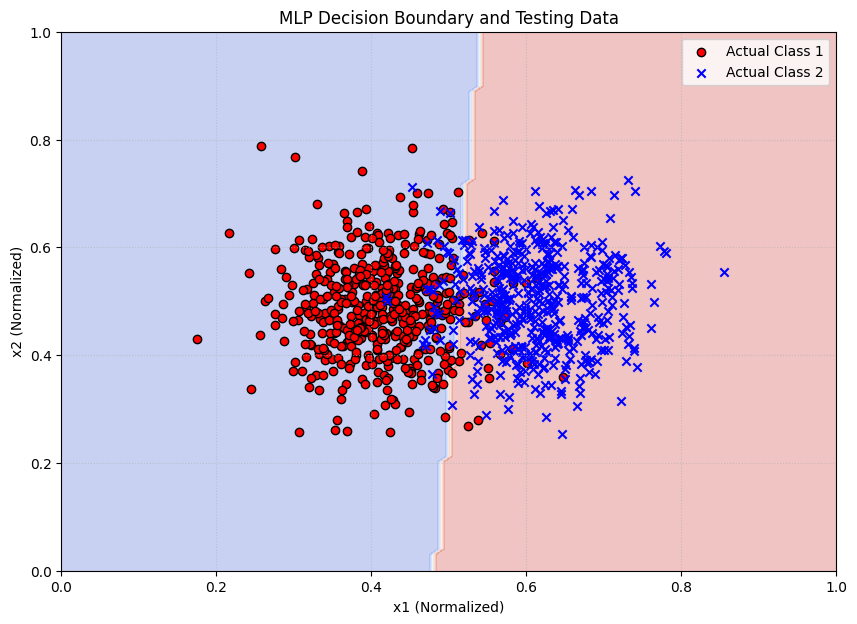

In [ ]:
import matplotlib.pyplot as plt

def plot_decision_boundary(X_test, y_test_actual, W1, W2):
    """
    Visualizes the classification results and the decision boundary.
    """
    x_min, x_max = 0.0, 1.0
    y_min, y_max = 0.0, 1.0
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_points_bias = np.hstack((grid_points, np.ones((grid_points.shape[0], 1))))
    
    net_h = np.dot(grid_points_bias, W1)
    out_h = 1 / (1 + np.exp(-net_h)) 
    out_h_bias = np.hstack((out_h, np.ones((out_h.shape[0], 1))))
    net_o = np.dot(out_h_bias, W2)
    out_o = 1 / (1 + np.exp(-net_o)) 
    
    predictions = np.where(out_o[:, 0] > out_o[:, 1], 1, 2)
    Z = predictions.reshape(xx.shape)

    plt.figure(figsize=(10, 7))
    
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    
    class1 = X_test[y_test_actual == 1]
    class2 = X_test[y_test_actual == 2]
    
    plt.scatter(class1[:, 0], class1[:, 1], color='red', marker='o', label='Actual Class 1', edgecolors='k')
    plt.scatter(class2[:, 0], class2[:, 1], color='blue', marker='x', label='Actual Class 2')

    plt.title('MLP Decision Boundary and Testing Data')
    plt.xlabel('x1 (Normalized)')
    plt.ylabel('x2 (Normalized)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

plot_decision_boundary(X_test, y_test_actual, W1, W2)